# SARIMA Univariate Analysis - All Target Variables  

| # | Variable | Description |
|---|----------|-------------|
| 1 | `electricity_local` | Local electricity consumption (GWh) |
| 2 | `air_so2` | Sulphur dioxide concentration |
| 3 | `air_no2` | Nitrogen dioxide concentration |
| 4 | `ipi_abs_index_sa` | Industrial Production Index (seasonally adjusted) |
| 5 | `car_registration` | Monthly car registrations |

### Justification for SARIMA as Main Model
- All five variables are montly time series with clear seasonal patterns
- SARIMA handles both trend and seasonality explicitly 
- Provides interpretable parameters, confidence intervals and statistical diagnostics - important for policy-relevant insights in Smart Government
- Variables are correlated, but we conduct univariate SARIMA per variable to establish standalone baselines

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os, warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pmdarima as pm

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
%matplotlib inline
print('Libraries loaded.')

Libraries loaded.


## 2. Load Dataset

In [3]:
df = pd.read_csv(r'c:/COS40007-Design-Project/COS40007DataCleaning/combined_air_electricity_ipi_cleaned.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True).set_index('date')
df.index.freq = 'MS'

TARGETS = ['electricity_local', 'air_so2', 'air_no2', 'ipi_abs_index_sa', 'car_registration']

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.index[0].date()} -> {df.index[-1].date()}')
print(f'Missing: {df[TARGETS].isnull().sum().sum()}\n')
print('Target variable summary:')
print(df[TARGETS].describe().round(4))

Dataset shape: (60, 19)
Date range: 2018-01-01 -> 2022-12-01
Missing: 0

Target variable summary:
       electricity_local  air_so2  air_no2  ipi_abs_index_sa  car_registration
count            60.0000  60.0000  60.0000           60.0000           60.0000
mean          12408.9877   0.0011   0.0065          116.3307        50819.0833
std             618.1074   0.0001   0.0010            7.9236        16592.0075
min           10349.1416   0.0009   0.0032           79.7660          129.0000
25%           12056.0772   0.0010   0.0061          113.0352        45202.5000
50%           12485.3755   0.0011   0.0065          115.1575        52460.0000
75%           12823.7684   0.0011   0.0074          120.3552        62934.5000
max           13463.7304   0.0013   0.0096          130.2930        76215.0000


## 3. Visualize All Target Variables

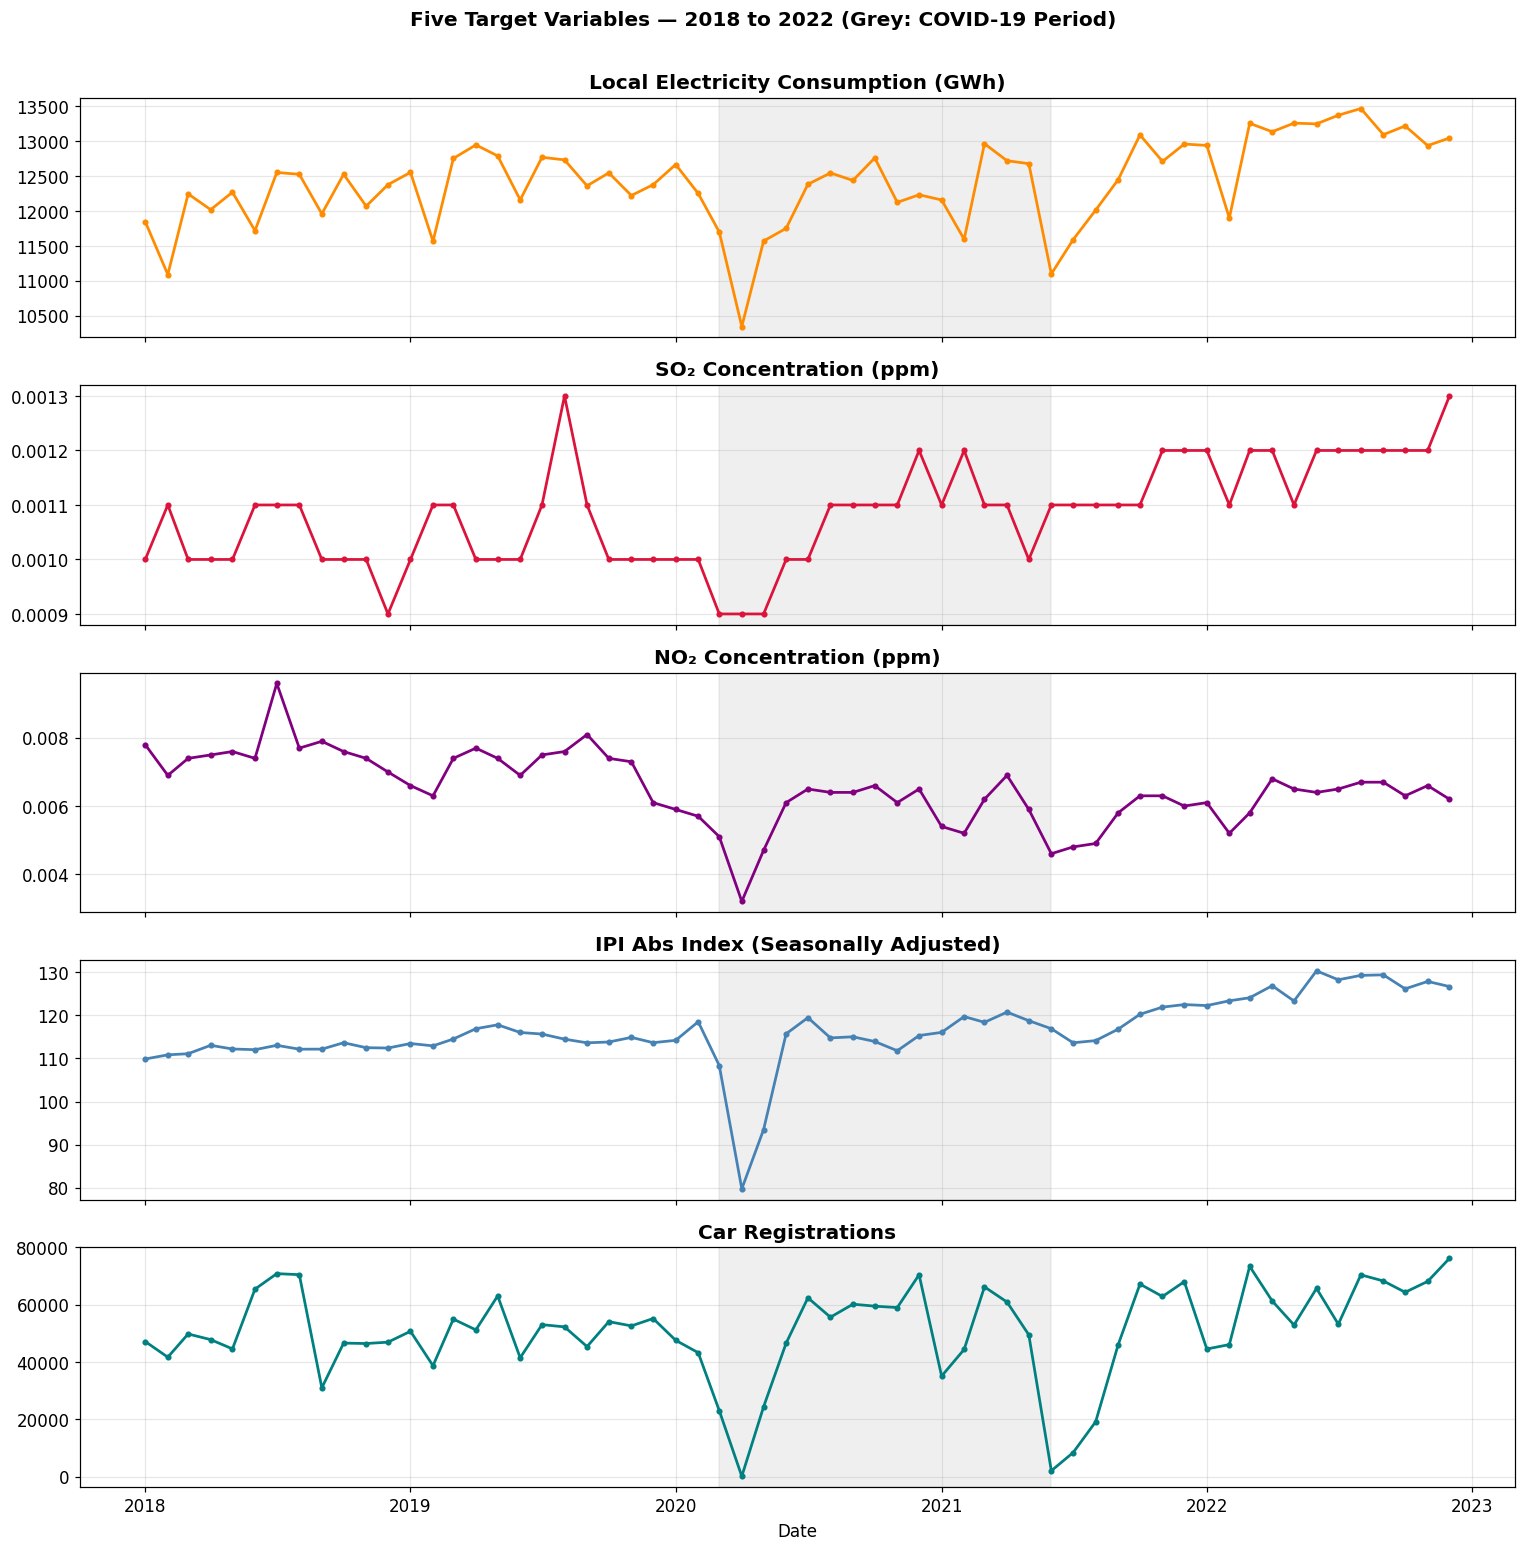

Saved: 00_overview_all_variables.png


In [4]:
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
colors = ['darkorange', 'crimson', 'purple', 'steelblue', 'teal']
labels_pretty = {
    'electricity_local': 'Local Electricity Consumption (GWh)',
    'air_so2': 'SO₂ Concentration (ppm)',
    'air_no2': 'NO₂ Concentration (ppm)',
    'ipi_abs_index_sa': 'IPI Abs Index (Seasonally Adjusted)',
    'car_registration': 'Car Registrations'
}

for ax, var, c in zip(axes, TARGETS, colors):
    ax.plot(df.index, df[var], color=c, linewidth=1.8, marker='o', markersize=3)
    ax.set_title(labels_pretty[var], fontweight='bold')
    ax.grid(alpha=0.3)
    # Shade COVID period
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), alpha=0.12, color='gray')

axes[-1].set_xlabel('Date')
plt.suptitle('Five Target Variables — 2018 to 2022 (Grey: COVID-19 Period)', fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('00_overview_all_variables.png', bbox_inches='tight')
plt.show()
print('Saved: 00_overview_all_variables.png')

## 4. Reusable SARIMA Pipeline

In [5]:
TRAIN_SIZE = 48  # 80% of 60 → train 2018–2021, test 2022
TEST_SIZE  = 12

def stationarity_summary(s):
    """Return a one-line summary of ADF and KPSS tests."""
    adf_p  = adfuller(s.dropna(), autolag='AIC')[1]
    kpss_p = kpss(s.dropna(), regression='c', nlags='auto')[1]
    adf_status  = 'PASS' if adf_p < 0.05 else 'FAIL'
    kpss_status = 'PASS' if kpss_p > 0.05 else 'FAIL'
    return f'ADF p={adf_p:.4f} {adf_status}, KPSS p={kpss_p:.4f} {kpss_status}'

def run_sarima_pipeline(series, var_name, verbose=False):
    """Run full SARIMA pipeline for one variable. Returns a dict with results."""
    train = series.iloc[:TRAIN_SIZE]
    test  = series.iloc[TRAIN_SIZE:]

    # Auto-ARIMA order search
    auto = pm.auto_arima(
        train,
        start_p=0, max_p=3, start_q=0, max_q=3, d=None,
        seasonal=True, m=12,
        start_P=0, max_P=2, start_Q=0, max_Q=2, D=None,
        information_criterion='aic',
        stepwise=True, suppress_warnings=True,
        error_action='ignore', trace=verbose
    )
    order, seasonal_order = auto.order, auto.seasonal_order

    # Fit SARIMA — add intercept ('c') when no differencing, matching auto_arima's default behaviour.
    # Without this, the model centers at 0, which is catastrophic for non-zero-mean series like IPI (~116) or car_reg (~50k).
    trend = 'c' if (order[1] == 0 and seasonal_order[1] == 0) else 'n'
    model = SARIMAX(
        train, order=order, seasonal_order=seasonal_order, trend=trend,
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)

    # Forecast
    fc_obj  = model.get_forecast(steps=len(test))
    fc_mean = fc_obj.predicted_mean
    fc_ci   = fc_obj.conf_int(alpha=0.05)
    fitted  = model.fittedvalues

    # Metrics
    def metrics(y_true, y_pred):
        return {
            'MAE' : mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAPE': np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
            'R2'  : r2_score(y_true, y_pred),
        }
    train_metrics = metrics(train.values, fitted.values)
    test_metrics  = metrics(test.values,  fc_mean.values)

    # Ljung-Box on residuals
    lb = acorr_ljungbox(model.resid, lags=[12], return_df=True)
    lb_p = lb['lb_pvalue'].iloc[0]

    return {
        'var_name': var_name,
        'order': order,
        'seasonal_order': seasonal_order,
        'aic': model.aic,
        'bic': model.bic,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'ljung_box_p': lb_p,
        'stationarity': stationarity_summary(series),
        'train': train,
        'test': test,
        'fitted': fitted,
        'forecast': fc_mean,
        'ci_lower': fc_ci.iloc[:, 0],
        'ci_upper': fc_ci.iloc[:, 1],
        'model': model,
    }

def plot_sarima_result(result, color='green'):
    """Plot actual vs forecast with 95% CI."""
    train, test  = result['train'], result['test']
    fc, lo, hi   = result['forecast'], result['ci_lower'], result['ci_upper']
    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.plot(train.index, train.values, label='Train', color='steelblue', linewidth=1.7)
    ax.plot(test.index,  test.values,  label='Actual (Test)', color='crimson', linewidth=2, marker='o', markersize=4)
    ax.plot(test.index,  fc.values,    label='SARIMA Forecast', color=color, linewidth=2, linestyle='--', marker='s', markersize=4)
    ax.fill_between(test.index, lo, hi, color=color, alpha=0.15, label='95% CI')
    ax.axvline(x=test.index[0], color='black', linestyle=':', linewidth=1)
    ax.set_title(f"{result['var_name']} — SARIMA{result['order']}x{result['seasonal_order']}", fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

print('Pipeline functions defined.')

Pipeline functions defined.


## 5. Run SARIMA on Each Variable

Run the pipeline below for each of the five variables and save the result. Each section displays:
- Selected SARIMA order
- AIC / BIC
- Test-set metrics
- Actual vs Forecast plot

### 5.1 Electricity Local

Stationarity   : ADF p=0.0005 PASS, KPSS p=0.0336 FAIL
Best order     : SARIMA(1, 0, 0)x(0, 0, 0, 12)
AIC / BIC      : 726.13 / 731.68
Test metrics   : {'MAE': 848.6243, 'RMSE': np.float64(878.3759), 'MAPE': np.float64(6.456), 'R2': -4.2176}
Ljung-Box p(12): 1.0000  PASS


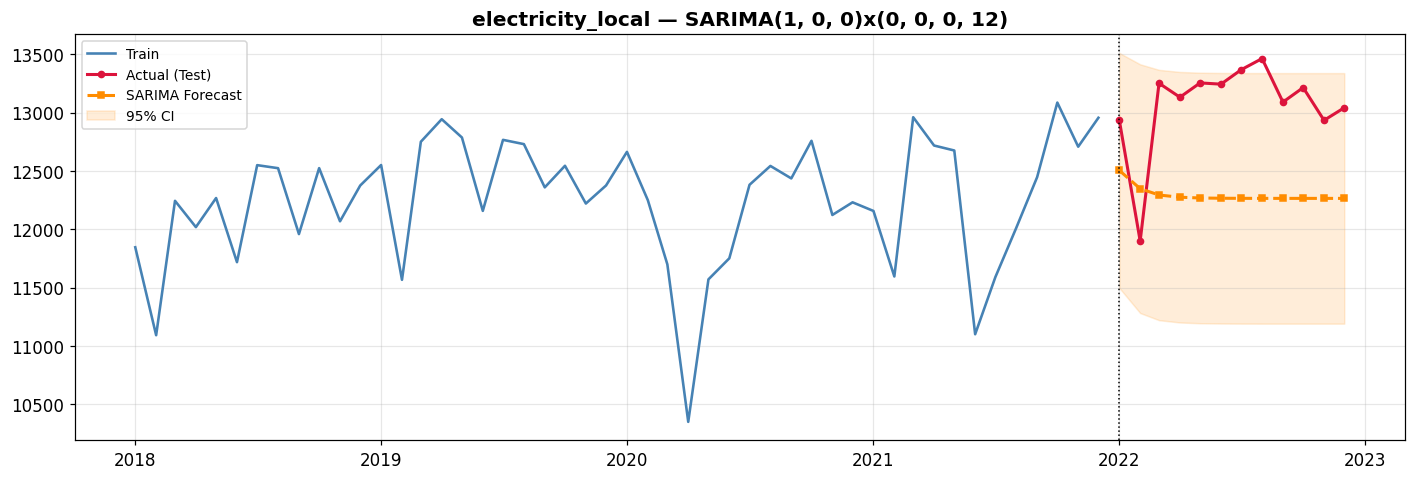

In [6]:
res_elec = run_sarima_pipeline(df['electricity_local'], 'electricity_local', verbose=False)
print(f"Stationarity   : {res_elec['stationarity']}")
print(f"Best order     : SARIMA{res_elec['order']}x{res_elec['seasonal_order']}")
print(f"AIC / BIC      : {res_elec['aic']:.2f} / {res_elec['bic']:.2f}")
print(f"Test metrics   : {({k: round(v, 4) for k,v in res_elec['test_metrics'].items()})}")
print(f"Ljung-Box p(12): {res_elec['ljung_box_p']:.4f}  {'PASS' if res_elec['ljung_box_p'] > 0.05 else 'WARN'}")
fig = plot_sarima_result(res_elec, color='darkorange')
plt.savefig('01_electricity_local_forecast.png', bbox_inches='tight')
plt.show()

### 5.2 Air SO2

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\USER\AppData\Local\Temp\ipykernel_10044\3074014725.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), regression='c', nlags='auto')[1]


Stationarity   : ADF p=0.9856 FAIL, KPSS p=0.0100 FAIL
Best order     : SARIMA(1, 0, 0)x(0, 0, 0, 12)
AIC / BIC      : -760.95 / -755.40
Test metrics   : {'MAE': 0.000114, 'RMSE': np.float64(0.000127), 'MAPE': np.float64(9.375184), 'R2': -5.662268}
Ljung-Box p(12): 0.9933  PASS


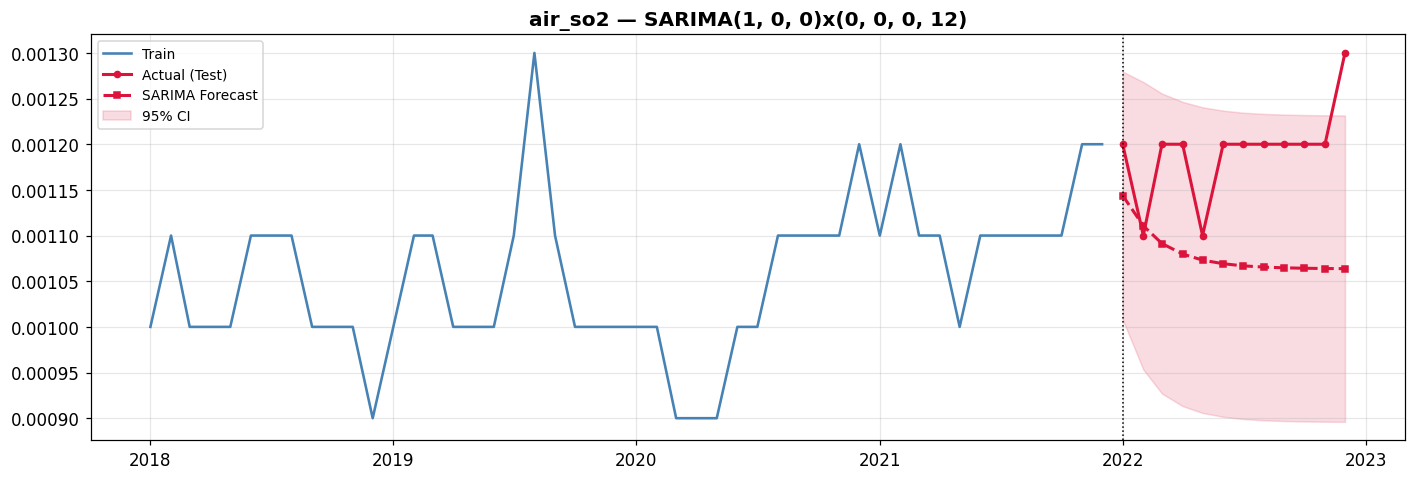

In [7]:
res_so2 = run_sarima_pipeline(df['air_so2'], 'air_so2', verbose=False)
print(f"Stationarity   : {res_so2['stationarity']}")
print(f"Best order     : SARIMA{res_so2['order']}x{res_so2['seasonal_order']}")
print(f"AIC / BIC      : {res_so2['aic']:.2f} / {res_so2['bic']:.2f}")
print(f"Test metrics   : {({k: round(v, 6) for k,v in res_so2['test_metrics'].items()})}")
print(f"Ljung-Box p(12): {res_so2['ljung_box_p']:.4f}  {'PASS' if res_so2['ljung_box_p'] > 0.05 else 'WARN'}")
fig = plot_sarima_result(res_so2, color='crimson')
plt.savefig('02_air_so2_forecast.png', bbox_inches='tight')
plt.show()

### 5.3 Air NO2

Stationarity   : ADF p=0.0759 FAIL, KPSS p=0.0190 FAIL
Best order     : SARIMA(0, 1, 0)x(0, 0, 0, 12)
AIC / BIC      : -524.11 / -522.28
Test metrics   : {'MAE': 0.000483, 'RMSE': np.float64(0.000537), 'MAPE': np.float64(7.653808), 'R2': -0.533235}
Ljung-Box p(12): 0.8039  PASS


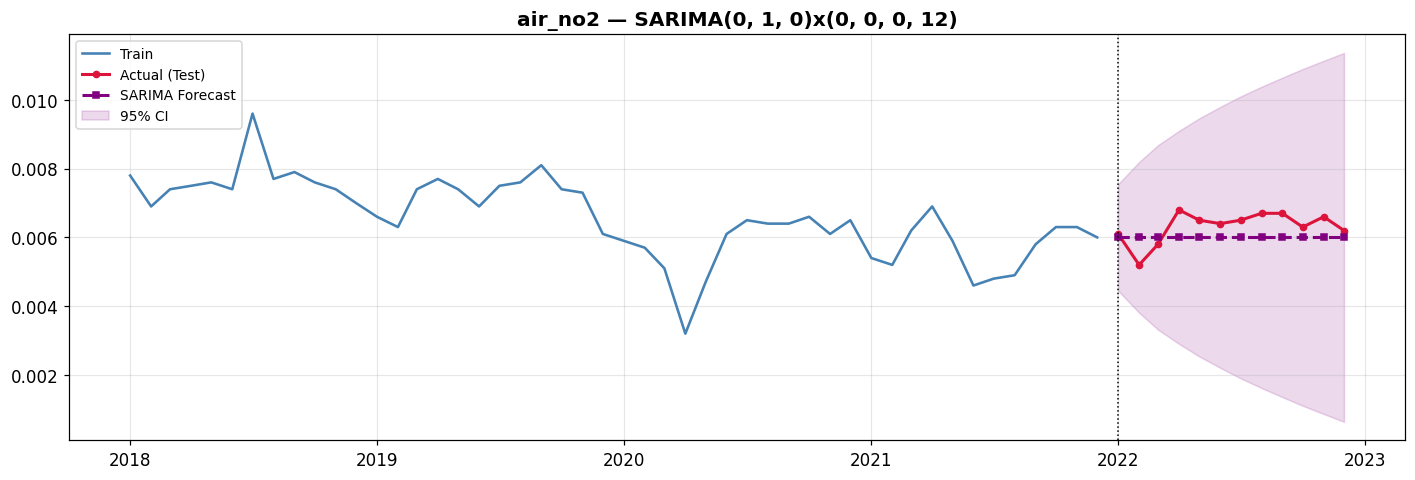

In [8]:
res_no2 = run_sarima_pipeline(df['air_no2'], 'air_no2', verbose=False)
print(f"Stationarity   : {res_no2['stationarity']}")
print(f"Best order     : SARIMA{res_no2['order']}x{res_no2['seasonal_order']}")
print(f"AIC / BIC      : {res_no2['aic']:.2f} / {res_no2['bic']:.2f}")
print(f"Test metrics   : {({k: round(v, 6) for k,v in res_no2['test_metrics'].items()})}")
print(f"Ljung-Box p(12): {res_no2['ljung_box_p']:.4f}  {'PASS' if res_no2['ljung_box_p'] > 0.05 else 'WARN'}")
fig = plot_sarima_result(res_no2, color='purple')
plt.savefig('03_air_no2_forecast.png', bbox_inches='tight')
plt.show()

### 5.4 IPI Absolute Index (Seasonally Adjusted)

C:\Users\USER\AppData\Local\Temp\ipykernel_10044\3074014725.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), regression='c', nlags='auto')[1]


Stationarity   : ADF p=0.3402 FAIL, KPSS p=0.0100 FAIL
Best order     : SARIMA(0, 0, 2)x(0, 0, 0, 12)
AIC / BIC      : 276.02 / 283.24
Test metrics   : {'MAE': 11.7894, 'RMSE': np.float64(12.3232), 'MAPE': np.float64(9.271), 'R2': -21.9766}
Ljung-Box p(12): 1.0000  PASS


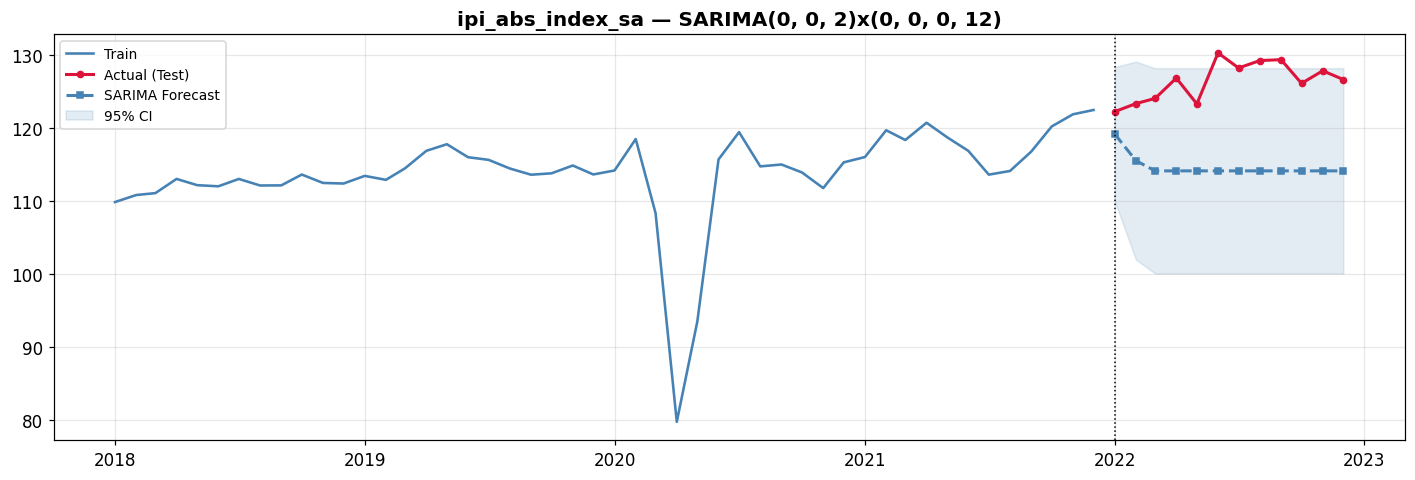

In [9]:
res_ipi = run_sarima_pipeline(df['ipi_abs_index_sa'], 'ipi_abs_index_sa', verbose=False)
print(f"Stationarity   : {res_ipi['stationarity']}")
print(f"Best order     : SARIMA{res_ipi['order']}x{res_ipi['seasonal_order']}")
print(f"AIC / BIC      : {res_ipi['aic']:.2f} / {res_ipi['bic']:.2f}")
print(f"Test metrics   : {({k: round(v, 4) for k,v in res_ipi['test_metrics'].items()})}")
print(f"Ljung-Box p(12): {res_ipi['ljung_box_p']:.4f}  {'PASS' if res_ipi['ljung_box_p'] > 0.05 else 'WARN'}")
fig = plot_sarima_result(res_ipi, color='steelblue')
plt.savefig('04_ipi_abs_index_sa_forecast.png', bbox_inches='tight')
plt.show()

### 5.5 Car Registrations

C:\Users\USER\AppData\Local\Temp\ipykernel_10044\3074014725.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s.dropna(), regression='c', nlags='auto')[1]


Stationarity   : ADF p=0.0026 PASS, KPSS p=0.1000 PASS
Best order     : SARIMA(3, 0, 0)x(0, 0, 0, 12)
AIC / BIC      : 992.23 / 1001.27
Test metrics   : {'MAE': 16366.75, 'RMSE': np.float64(18879.77), 'MAPE': np.float64(24.71), 'R2': -2.51}
Ljung-Box p(12): 0.1171  PASS


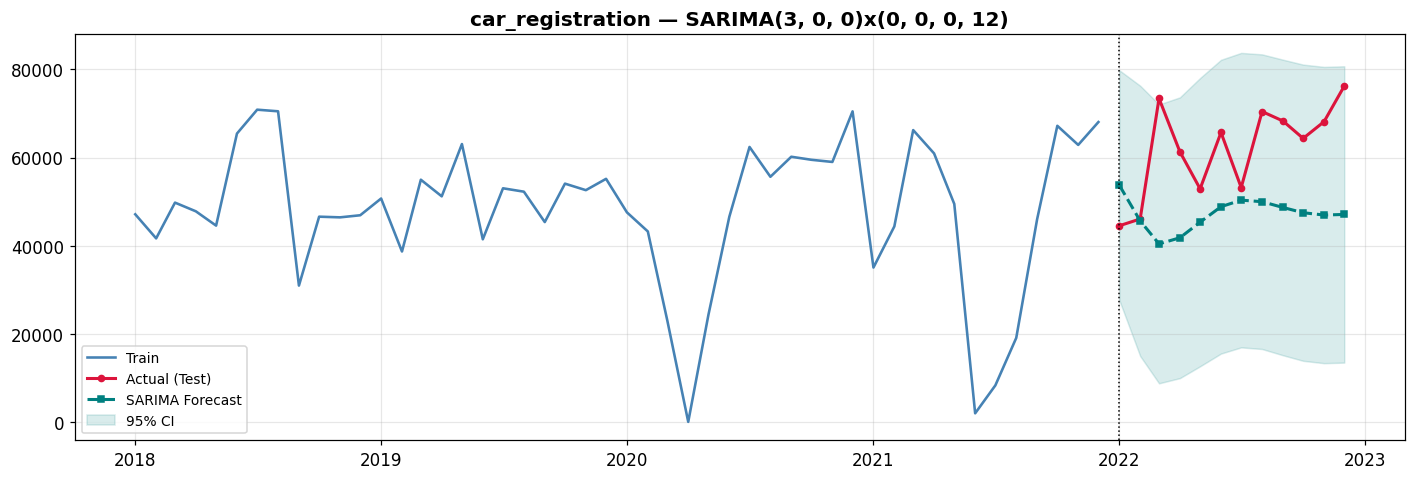

In [10]:
res_car = run_sarima_pipeline(df['car_registration'], 'car_registration', verbose=False)
print(f"Stationarity   : {res_car['stationarity']}")
print(f"Best order     : SARIMA{res_car['order']}x{res_car['seasonal_order']}")
print(f"AIC / BIC      : {res_car['aic']:.2f} / {res_car['bic']:.2f}")
print(f"Test metrics   : {({k: round(v, 2) for k,v in res_car['test_metrics'].items()})}")
print(f"Ljung-Box p(12): {res_car['ljung_box_p']:.4f}  {'PASS' if res_car['ljung_box_p'] > 0.05 else 'WARN'}")
fig = plot_sarima_result(res_car, color='teal')
plt.savefig('05_car_registration_forecast.png', bbox_inches='tight')
plt.show()

## 6. Combined Forecast Plot (All Variables)

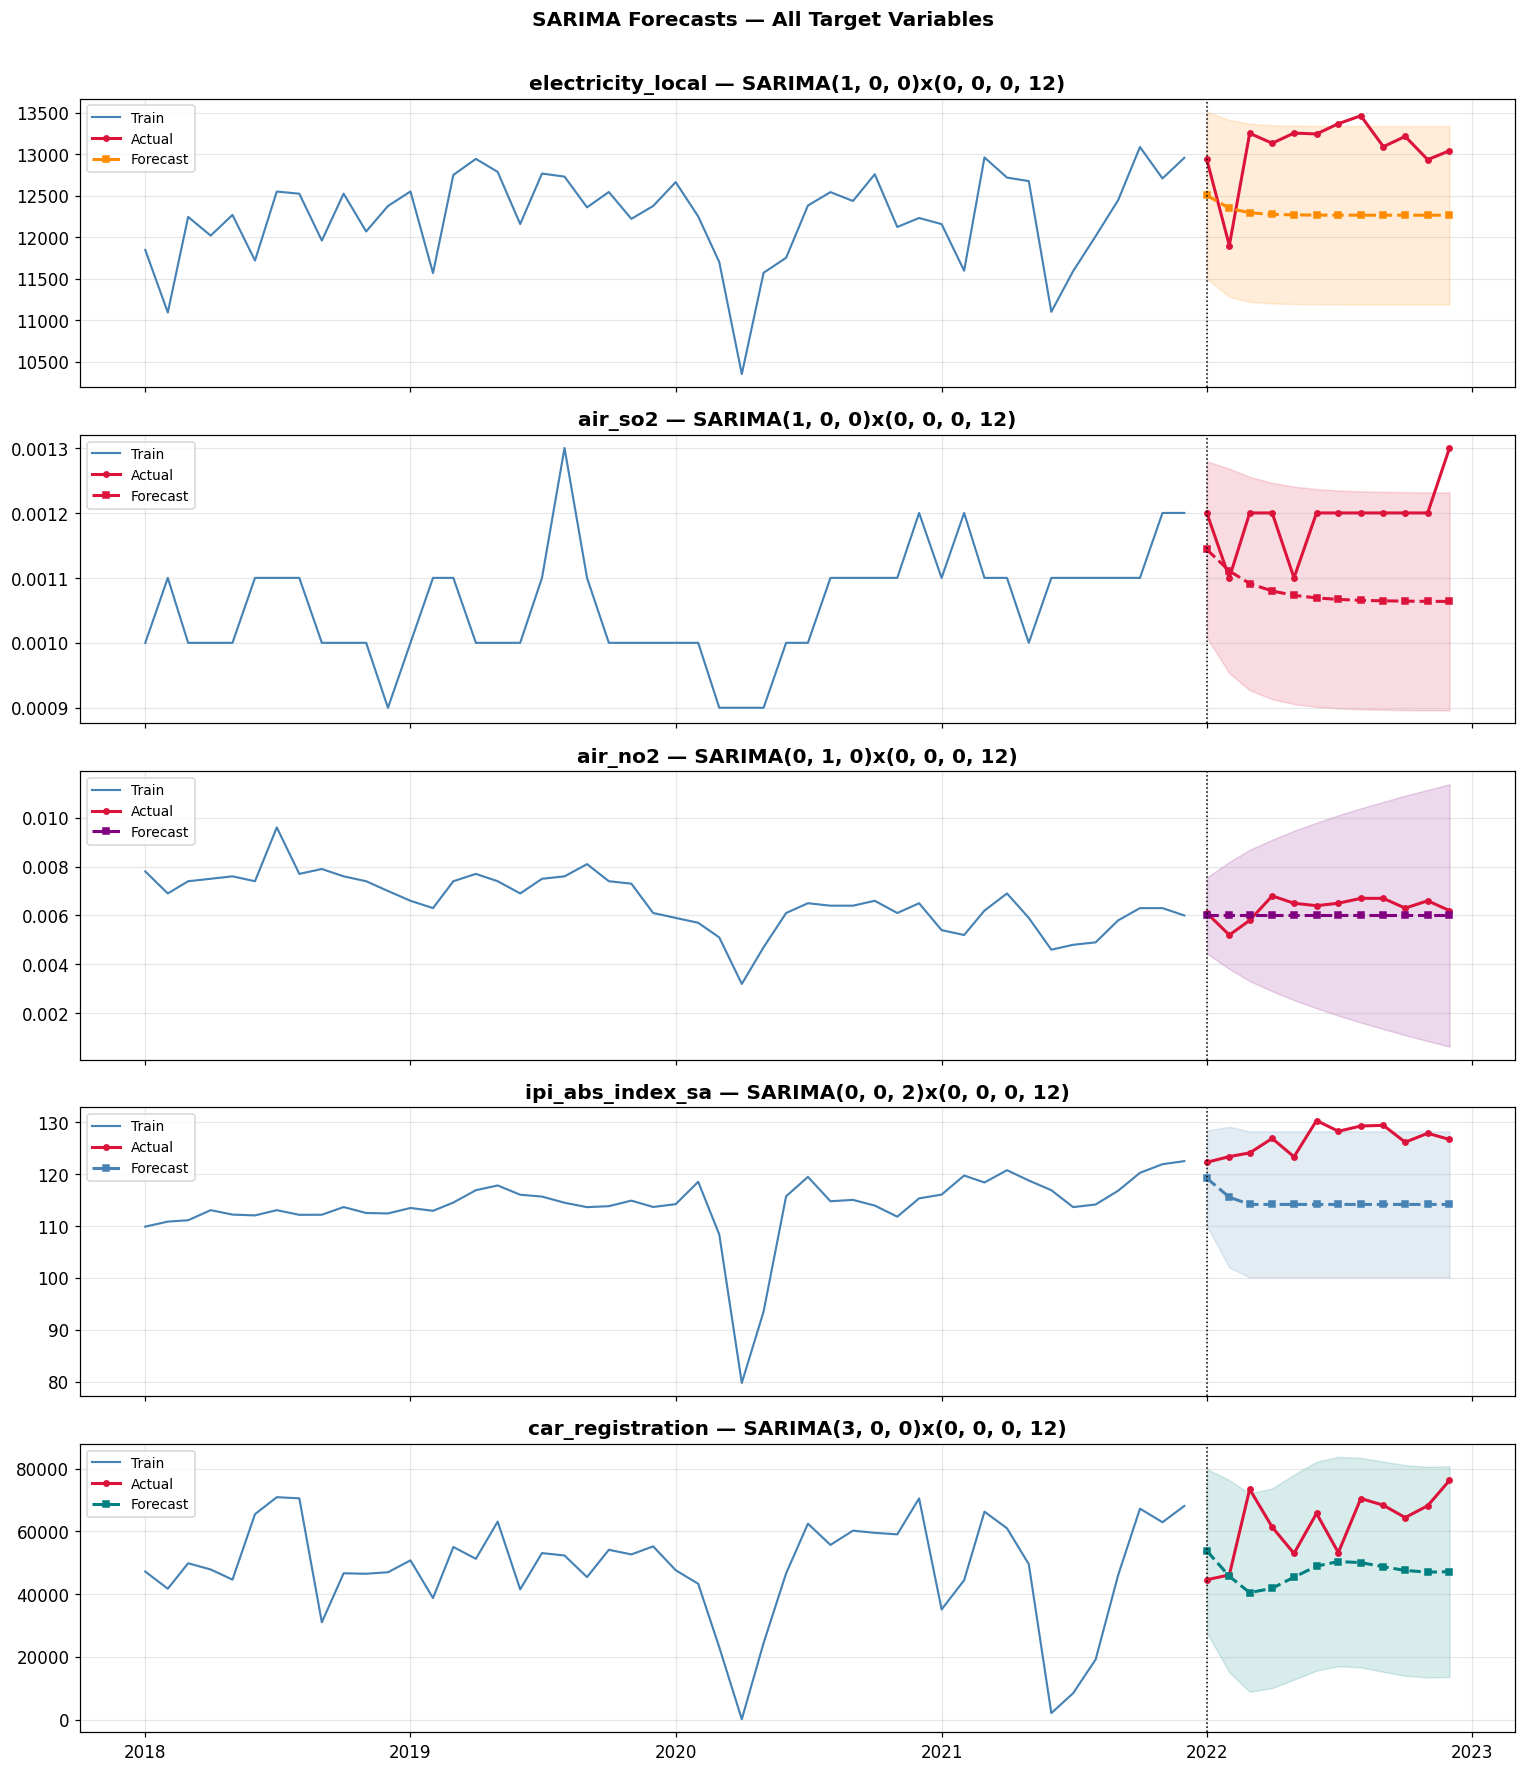

Saved: 06_combined_forecasts.png


In [11]:
all_results = [res_elec, res_so2, res_no2, res_ipi, res_car]
all_colors  = ['darkorange', 'crimson', 'purple', 'steelblue', 'teal']

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
for ax, result, c in zip(axes, all_results, all_colors):
    train, test = result['train'], result['test']
    fc, lo, hi  = result['forecast'], result['ci_lower'], result['ci_upper']
    ax.plot(train.index, train.values, color='steelblue', linewidth=1.4, label='Train')
    ax.plot(test.index,  test.values,  color='crimson', linewidth=2, marker='o', markersize=3.5, label='Actual')
    ax.plot(test.index,  fc.values,    color=c, linewidth=2, linestyle='--', marker='s', markersize=3.5, label='Forecast')
    ax.fill_between(test.index, lo, hi, color=c, alpha=0.15)
    ax.axvline(x=test.index[0], color='black', linestyle=':', linewidth=1)
    ax.set_title(f"{result['var_name']} — SARIMA{result['order']}x{result['seasonal_order']}", fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('SARIMA Forecasts — All Target Variables', fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('06_combined_forecasts.png', bbox_inches='tight')
plt.show()
print('Saved: 06_combined_forecasts.png')

## 7. Comparison Summary Table

In [12]:
rows = []
for r in all_results:
    rows.append({
        'Variable'      : r['var_name'],
        'Order'         : f"{r['order']}x{r['seasonal_order']}",
        'AIC'           : round(r['aic'], 2),
        'BIC'           : round(r['bic'], 2),
        'Test MAE'      : round(r['test_metrics']['MAE'], 4),
        'Test RMSE'     : round(r['test_metrics']['RMSE'], 4),
        'Test MAPE (%)' : round(r['test_metrics']['MAPE'], 2),
        'Test R²'       : round(r['test_metrics']['R2'], 4),
        'LjungBox p'    : round(r['ljung_box_p'], 4),
    })

summary_df = pd.DataFrame(rows)
print('='*100)
print('  SARIMA Univariate Results — All 5 Target Variables')
print('='*100)
print(summary_df.to_string(index=False))
print('='*100)

summary_df.to_csv('sarima_univariate_summary.csv', index=False)
print('\nSaved: sarima_univariate_summary.csv')

  SARIMA Univariate Results — All 5 Target Variables
         Variable                   Order     AIC     BIC   Test MAE  Test RMSE  Test MAPE (%)  Test R²  LjungBox p
electricity_local (1, 0, 0)x(0, 0, 0, 12)  726.13  731.68   848.6243   878.3759           6.46  -4.2176      1.0000
          air_so2 (1, 0, 0)x(0, 0, 0, 12) -760.95 -755.40     0.0001     0.0001           9.38  -5.6623      0.9933
          air_no2 (0, 1, 0)x(0, 0, 0, 12) -524.11 -522.28     0.0005     0.0005           7.65  -0.5332      0.8039
 ipi_abs_index_sa (0, 0, 2)x(0, 0, 0, 12)  276.02  283.24    11.7894    12.3232           9.27 -21.9766      1.0000
 car_registration (3, 0, 0)x(0, 0, 0, 12)  992.23 1001.27 16366.7527 18879.7706          24.71  -2.5147      0.1171

Saved: sarima_univariate_summary.csv


## 8. Save Per-Variable Forecast CSVs

In [13]:
os.makedirs('forecasts', exist_ok=True)
for r in all_results:
    fc_df = pd.DataFrame({
        'Date': r['test'].index,
        'Actual': r['test'].values,
        'Predicted': r['forecast'].values,
        'CI_Lower': r['ci_lower'].values,
        'CI_Upper': r['ci_upper'].values,
    })
    fc_df['Abs_Error'] = (fc_df['Actual'] - fc_df['Predicted']).abs()
    fc_df['Pct_Error'] = (fc_df['Abs_Error'] / fc_df['Actual'].abs() * 100).round(2)
    fname = f"forecasts/{r['var_name']}_forecast.csv"
    fc_df.to_csv(fname, index=False)
    print(f'Saved: {fname}')

# Save full JSON summary
json_summary = {
    'project': 'COS40007 Design Project — SARIMA Univariate',
    'dataset_period': f'{df.index[0].date()} to {df.index[-1].date()}',
    'train_size': TRAIN_SIZE,
    'test_size': TEST_SIZE,
    'results': [
        {
            'variable': r['var_name'],
            'order': str(r['order']),
            'seasonal_order': str(r['seasonal_order']),
            'aic': round(r['aic'], 4),
            'bic': round(r['bic'], 4),
            'train_metrics': {k: round(v, 6) for k, v in r['train_metrics'].items()},
            'test_metrics':  {k: round(v, 6) for k, v in r['test_metrics'].items()},
            'ljung_box_p_lag12': round(r['ljung_box_p'], 6),
        }
        for r in all_results
    ]
}
with open('sarima_univariate_summary.json', 'w') as f:
    json.dump(json_summary, f, indent=2)
print('\nSaved: sarima_univariate_summary.json')

Saved: forecasts/electricity_local_forecast.csv
Saved: forecasts/air_so2_forecast.csv
Saved: forecasts/air_no2_forecast.csv
Saved: forecasts/ipi_abs_index_sa_forecast.csv
Saved: forecasts/car_registration_forecast.csv

Saved: sarima_univariate_summary.json
